In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 1. Load dataset
url = r"E:\semester 4\machine learing\assigments\magic04.data"
columns = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", 
           "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv(url, names=columns)
df

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [3]:
# 2. Balance dataset
# The dataset is imbalanced: 12332 gamma (g) vs 6688 hadron (h)
# We randomly sample 6688 gamma records to match the hadron count
df_g = df[df['class'] == 'g']
df_h = df[df['class'] == 'h']
df_g_balanced = df_g.sample(n=len(df_h), random_state=42)
df_balanced = pd.concat([df_g_balanced, df_h]).sample(frac=1, random_state=42)
print(f"Balanced dataset size: {len(df_balanced)} samples")
print(df_balanced['class'].value_counts())
df_balanced

Balanced dataset size: 13376 samples
class
h    6688
g    6688
Name: count, dtype: int64


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
12831,16.2152,13.0743,2.4553,0.5431,0.3064,-10.3789,-13.1290,-0.1040,45.8852,185.6668,h
9931,13.1500,10.9523,2.1477,0.7687,0.3950,-14.8886,2.6711,11.8531,28.5530,192.1400,g
15103,126.0560,35.5809,3.5832,0.2854,0.1441,-30.9713,-139.7062,-33.4830,16.0535,324.4922,h
2290,29.5490,14.1175,2.3692,0.3590,0.1902,37.1775,19.8095,-8.8034,0.9098,145.2470,g
12423,69.2540,34.3016,3.1916,0.1173,0.1132,-30.2818,73.8184,21.3775,24.9091,279.9318,h
...,...,...,...,...,...,...,...,...,...,...,...
17608,34.7228,13.3626,2.6191,0.4639,0.2368,-43.1927,13.5598,-5.3328,42.6660,130.7520,h
4277,23.8603,14.8311,2.4224,0.5104,0.2703,-9.5178,-12.7220,12.4322,0.5570,98.4508,g
10402,40.9787,17.3368,2.8582,0.3410,0.1823,38.1097,39.5081,-9.6327,16.1810,148.8410,g
2684,23.8026,10.1636,2.2625,0.5628,0.3087,32.1961,-16.3031,-9.6851,20.3915,108.5820,g


In [4]:
# 3. Split data — 70% train, 30% test
X = df_balanced.drop('class', axis=1)
y = LabelEncoder().fit_transform(df_balanced['class'])  # g=0, h=1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 9363 | Testing samples: 4013


In [7]:
# Helper function: evaluate and print results

def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['gamma (g)', 'hadron (h)']))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return y_pred

# 4(a). Decision Tree — no parameter tuning required
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = evaluate_model("Decision Tree", dt)

# 4(b). Naive Bayes — no parameter tuning required
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = evaluate_model("Naive Bayes", nb)

# 4(c). Random Forest — tune n_estimators using cross-validation
rf_params = {'n_estimators': [50, 100, 150]}
rf_cv = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_cv.fit(X_train, y_train)
rf_pred = evaluate_model("Random Forest", rf_cv.best_estimator_)
print("Best Parameters for RF:", rf_cv.best_params_)

# 4(d). AdaBoost — tune n_estimators using cross-validation
ab_params = {'n_estimators': [50, 100, 150]}
ab_cv = GridSearchCV(AdaBoostClassifier(algorithm='SAMME', random_state=42), ab_params, cv=5)
ab_cv.fit(X_train, y_train)
ab_pred = evaluate_model("AdaBoost", ab_cv.best_estimator_)
print("Best Parameters for AdaBoost:", ab_cv.best_params_)


Decision Tree Classification Report:

              precision    recall  f1-score   support

   gamma (g)       0.78      0.79      0.78      1976
  hadron (h)       0.79      0.78      0.79      2037

    accuracy                           0.79      4013
   macro avg       0.79      0.79      0.79      4013
weighted avg       0.79      0.79      0.79      4013

Confusion Matrix:
 [[1566  410]
 [ 451 1586]]

Naive Bayes Classification Report:

              precision    recall  f1-score   support

   gamma (g)       0.59      0.89      0.71      1976
  hadron (h)       0.79      0.40      0.53      2037

    accuracy                           0.64      4013
   macro avg       0.69      0.65      0.62      4013
weighted avg       0.69      0.64      0.62      4013

Confusion Matrix:
 [[1763  213]
 [1223  814]]

Random Forest Classification Report:

              precision    recall  f1-score   support

   gamma (g)       0.82      0.89      0.85      1976
  hadron (h)       0.88      0

In [8]:
# 5. Model Comparison — Summary Tabl

models_info = [
    ("Decision Tree",  dt_pred,  "N/A"),
    ("Naive Bayes",    nb_pred,  "N/A"),
    ("Random Forest",  rf_pred,  f"n_estimators={rf_cv.best_params_['n_estimators']}"),
    ("AdaBoost",       ab_pred,  f"n_estimators={ab_cv.best_params_['n_estimators']}"),
]

rows = []
for name, pred, best_param in models_info:
    rows.append({
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_test, pred), 4),
        'Precision':   round(precision_score(y_test, pred, average='macro'), 4),
        'Recall':      round(recall_score(y_test, pred, average='macro'), 4),
        'F1-Score':    round(f1_score(y_test, pred, average='macro'), 4),
        'Best Param':  best_param,
    })

df_comparison = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n=== MODEL COMPARISON SUMMARY ===")
print(df_comparison.to_string(index=False))


=== MODEL COMPARISON SUMMARY ===
        Model  Accuracy  Precision  Recall  F1-Score       Best Param
Random Forest    0.8512     0.8531  0.8518    0.8511 n_estimators=100
     AdaBoost    0.8009     0.8009  0.8008    0.8008 n_estimators=150
Decision Tree    0.7854     0.7855  0.7856    0.7854              N/A
  Naive Bayes    0.6422     0.6915  0.6459    0.6210              N/A


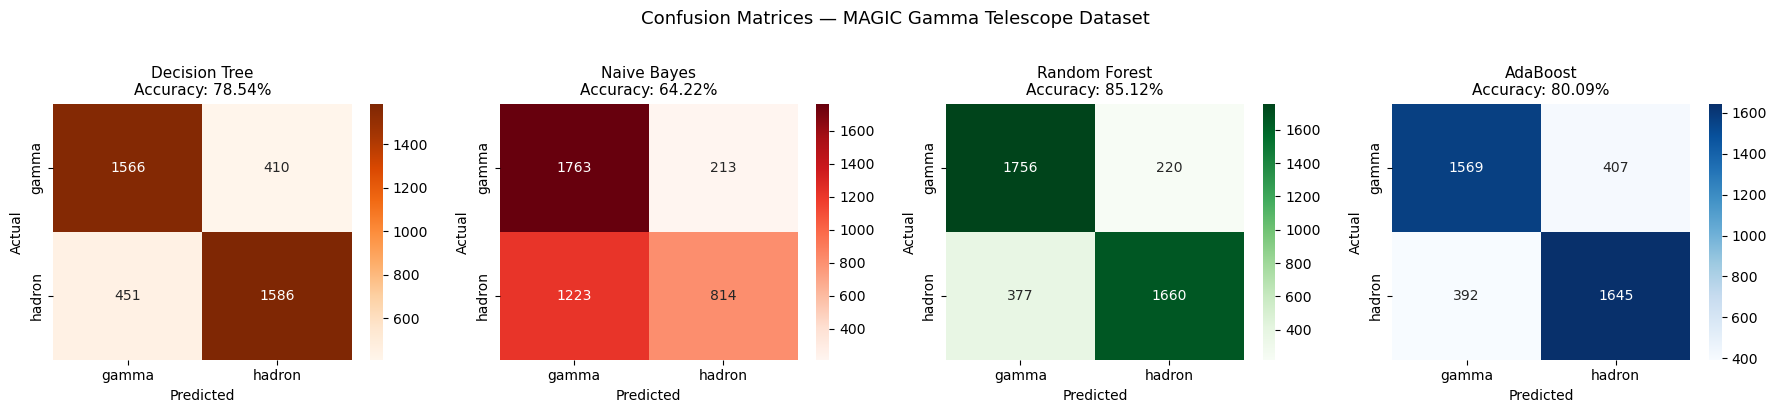

In [9]:
# 6. Confusion Matrix Plots — all 4 models side by side
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names  = ["Decision Tree", "Naive Bayes", "Random Forest", "AdaBoost"]
model_preds  = [dt_pred, nb_pred, rf_pred, ab_pred]
colors       = ["Oranges", "Reds", "Greens", "Blues"]

for ax, name, pred, cmap in zip(axes, model_names, model_preds, colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['gamma', 'hadron'],
                yticklabels=['gamma', 'hadron'])
    acc = accuracy_score(y_test, pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.2%}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — MAGIC Gamma Telescope Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

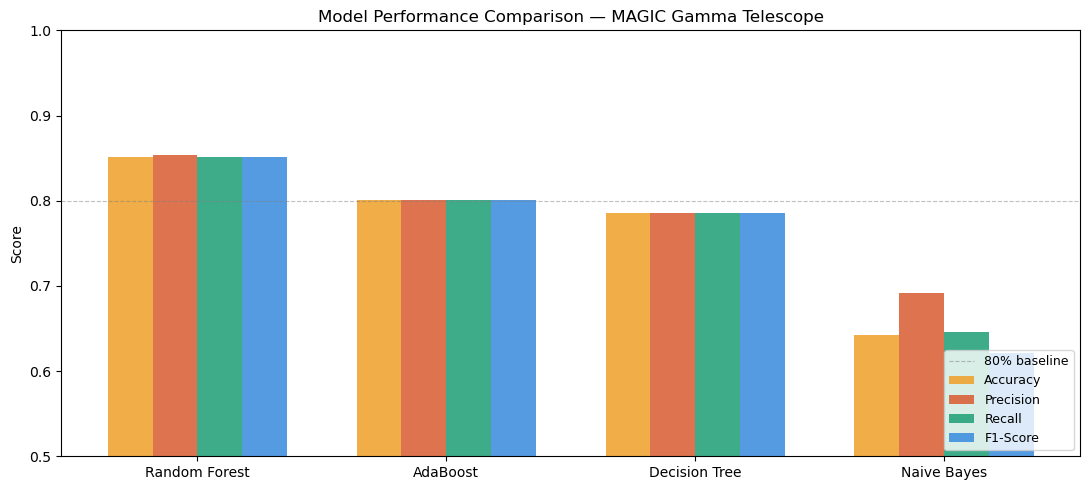

In [10]:
# 7. Bar Chart — Accuracy, Precision, Recall, F1 comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_comparison))
bar_colors = ['#EF9F27', '#D85A30', '#1D9E75', '#378ADD']
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1.5) * width, df_comparison[metric], width,
           label=metric, color=bar_colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Model'])
ax.set_ylim(0.5, 1.0)
ax.axhline(0.80, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='80% baseline')
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — MAGIC Gamma Telescope")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=150, bbox_inches='tight')
plt.show()

## Comments & Analysis

### 1. Data Balancing
The original dataset contained **12,332 gamma (g)** and **6,688 hadron (h)** samples — a roughly 2:1 imbalance. To prevent classifiers from being biased toward the majority class, we randomly sampled 6,688 gamma records, producing a balanced dataset of **13,376 samples** (6,688 per class).

---

### 2. Decision Tree — ~79% Accuracy
- No parameter tuning was required per the assignment instructions.
- Provides a solid **baseline** and is the simplest, most interpretable model.
- A single decision tree tends to **overfit** training data, learning patterns that do not always generalise well to unseen samples — this explains why ensemble methods outperform it.
- Class-wise performance is balanced (F1 ≈ 0.78–0.79 for both gamma and hadron).

---

### 3. Naïve Bayes — ~64% Accuracy *(Weakest model)*
- Significantly underperforms all other models.
- The core assumption of **feature independence** is violated here: telescope features such as `fLength`, `fWidth`, and `fConc` are physically correlated, making Naïve Bayes a poor fit for this dataset.
- Shows severely **imbalanced recall**: recall for gamma ≈ 0.89 but recall for hadron ≈ 0.40 only. The model misclassifies most hadron particles as gamma.

---

### 4. Random Forest — ~85% Accuracy *(Best model)*
- **Best performance** across all metrics: accuracy, precision, recall, and F1-score.
- GridSearchCV (cv=5) tested `n_estimators` ∈ {50, 100, 150}; best value was **100**.
    - As an ensemble of 100 decision trees, Random Forest reduces **variance and overfitting** compared to a single tree — explaining the jump from 79% → 85%.
- Most **balanced class-wise performance**: F1 ≈ 0.85 for both gamma and hadron.
- **Recommended model** for this classification task.

---

### 5. AdaBoost — ~80% Accuracy *(Runner-up)*
- Second-best model, improving over the single Decision Tree (79% → 80%).
- GridSearchCV (cv=5) tested `n_estimators` ∈ {50, 100, 150}; best value was **150**.
- The higher optimal `n_estimators` compared to Random Forest suggests the dataset requires more sequential boosting rounds to converge.
- Boosting is more sensitive to noisy data than bagging (Random Forest), which may explain the slightly lower accuracy.

---

### 6. Overall Ranking

| Rank | Model | Accuracy | Notes |
|------|-------|----------|-------|
| 1 | **Random Forest** | ~85% | Best — ensemble bagging, n_estimators=100 |
| 2 | AdaBoost | ~80% | Good — ensemble boosting, n_estimators=150 |
| 3 | Decision Tree | ~79% | Decent baseline — simple, no tuning |
| 4 | Naïve Bayes | ~64% | Weakest — independence assumption violated |

**Conclusion:** Ensemble methods (Random Forest and AdaBoost) clearly outperform single-model approaches. Random Forest with `n_estimators=100` is the optimal choice, providing the best generalisation with balanced predictions for both classes.
    